# Individualized Frequency Estimation from Task-Locked EEG
## Feedback- and Decision-Locked Analysis for tACS Frequency Selection

**Goal:** Estimate participant-specific oscillatory peak frequencies (theta, beta, alpha) from EEG recorded during the two-armed bandit task, plus an exploratory measure of theta-gamma phase-amplitude coupling strength.

### Methods & Precedents

**Primary approach — task-locked spectral power (Bjekić et al., 2022; van Driel et al., 2015):**
Extract the frequency with peak event-related spectral perturbation (ERSP) from task-locked epochs at frontal electrodes. Bjekić et al. (2022, *J. Personalized Medicine*) demonstrated 93% success rate for individualized theta frequency (ITF) extraction using this approach across 42 participants in an associative memory task. Van Driel et al. (2015) used automatic peak detection on log-transformed, 1/f-detrended power spectra during a cognitive inhibition task.

**Validation layer — spectral parameterization (Donoghue et al., 2020):**
Specparam (formerly FOOOF) decomposes the power spectrum into aperiodic (1/f) and periodic (oscillatory) components, confirming whether a peak reflects a genuine oscillation or just the aperiodic slope. Applied here to the feedback-window spectrum.

**Supplementary — PLV (Reinhart & Nguyen, 2019):**
Phase-locking value between frontal and posterior channels, retained as a supplementary connectivity metric. Reinhart & Nguyen (2019, *Nature Neuroscience*) used PLV for two-site stimulation targeting inter-regional synchronization. For single-site frontal tACS (our design), power-based estimation is more appropriate, but PLV is reported for completeness and potential use as a moderator variable.

**Exploratory — theta-gamma PAC:**
Phase-amplitude coupling strength between theta phase and low-gamma amplitude, computed as a participant-level summary metric. Not used for frequency selection, but potentially informative as a moderator of tACS response (deficiency compensation hypothesis).

### Frequency bands and task relevance

| Band | Range | Task phase | Role in bandit/RL |
|------|-------|-----------|-------------------|
| **Theta** (4–8 Hz) | Primary target | Feedback (0–1.5s post-outcome) | Prediction error, adaptive control (Cavanagh & Frank, 2014) |
| **Beta** (13–30 Hz) | Secondary | Decision (pre-response) AND feedback | Exploration vs. exploitation; policy maintenance (Sporn et al., 2023; Holroyd et al., 2020) |
| **Alpha** (8–13 Hz) | Reference | Resting / inter-trial | Gating/inhibition; IAF as anchor for ITF (Klimesch, 1999) |
| **Gamma** (30–45 Hz) | Exploratory | Feedback | Theta-gamma coupling in RL circuits (cross-frequency only) |

**Montage:** 1=F3, 2=Fp1, 3=FCz, 4=FT7, 5=F4, 6=P4, 7=P3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import warnings, time
warnings.filterwarnings('ignore', category=RuntimeWarning)

try:
    from specparam import SpectralModel
    SPECPARAM_AVAILABLE = True
    print(f"specparam v{__import__('specparam').__version__}")
except ImportError:
    SPECPARAM_AVAILABLE = False
    print("specparam not installed — pip install specparam")

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.labelsize': 12,
                     'axes.titlesize': 13, 'font.size': 11, 'lines.linewidth': 1.5})


specparam v2.0.0rc6


## Step 0: Configuration

In [7]:
# ══════════════════════════════════════════════════════════════
# FILE PATHS
# ══════════════════════════════════════════════════════════════
EASY_FILE = Path("~/Documents/GitHub/tacs_bandit/data/nic/raw/20260602150340_sub-rebecca-pilot-2_Run 1.easy").expanduser()
BEHAV_CSV = Path("~/Documents/GitHub/tacs_bandit/data/bandit/sub-rebecca-pilot-2/sub-rebecca-pilot-2_ses-1_run-01_task-bandit_2026-06-02_15-02-09.csv").expanduser()

# Channel mapping
CHANNEL_MAP = {0:'F3', 1:'Fp1', 2:'FCz', 3:'FT7', 4:'F4', 5:'P4', 6:'P3'}
N_EEG_CH = 7
SRATE = 500
NV_TO_UV = 1e-3

# ROIs
FRONTAL_ROI = ['FCz', 'F3', 'F4']
POSTERIOR_ROI = ['FT7', 'P3', 'P4']
POSTERIOR_ALPHA_ROI = ['P3', 'P4']

# Preprocessing
HIGHPASS = 0.5
LOWPASS = 45.0
NOTCH = 60.0

# Epoch windows (relative to feedback onset)
EPOCH_TMIN = -1.5   # 1.5s pre-feedback
EPOCH_TMAX = 2.0    # 2s post-feedback
BASELINE_WIN = (-0.8, -0.1)
FEEDBACK_WIN = (0.1, 1.5)       # theta/beta analysis post-feedback

# Decision-phase epochs: we'll define these relative to response onset
# (trial_start_time + stimulus viewing, ending at RT)
DECISION_PRE_RESP = (-1.0, -0.1)  # 1s to 100ms before response

# Frequency bands
BANDS = {
    'theta':  (4.0, 8.0),
    'alpha':  (8.0, 13.0),
    'beta':   (13.0, 30.0),
}

# Theta sweep resolution
THETA_STEP = 0.25
BETA_STEP = 0.5

# Artifact rejection
EPOCH_REJECT_UV = 200.0

# Fixed stimulation frequency (for frequency-match analysis)
STIM_FREQ_HZ = 6.0


## Step 1: Load EEG & Behavioral Data

In [10]:
# ── Load .easy file ──
print("Loading EEG...")
raw = np.loadtxt(EASY_FILE)
eeg_nv = raw[:, :N_EEG_CH]
markers_col = raw[:, N_EEG_CH]
ts_ms = raw[:, -1]
eeg_uv = eeg_nv * NV_TO_UV
ch_names = [CHANNEL_MAP[i] for i in range(N_EEG_CH)]
n_samples = len(eeg_uv)
duration_s = n_samples / SRATE

print(f"  Shape: {raw.shape} ({n_samples:,} samples, {raw.shape[1]} cols)")
print(f"  Duration: {duration_s:.1f}s ({duration_s/60:.1f} min)")
print(f"  Channels: {ch_names}")

# ── Load behavioral CSV ──
print("\nLoading behavior...")
bdf = pd.read_csv(BEHAV_CSV)
bdf['rt_sec'] = bdf['rt'] / 1000.0
print(f"  Trials: {len(bdf)}")
print(f"  trial_start_time range: {bdf['trial_start_time'].min():.2f} – {bdf['trial_start_time'].max():.2f} s")

# Compute event times
bdf['feedback_onset'] = bdf['trial_start_time'] + bdf['rt_sec'] + 2.0  # +2s wait
bdf['response_time'] = bdf['trial_start_time'] + bdf['rt_sec']         # response moment

print(f"  Feedback onset range: {bdf['feedback_onset'].min():.2f} – {bdf['feedback_onset'].max():.2f} s")
print(f"  Response time range: {bdf['response_time'].min():.2f} – {bdf['response_time'].max():.2f} s")
print(f"  Reward: {bdf['reward'].sum()} / {len(bdf)}")


Loading EEG...
  Shape: (180000, 13) (180,000 samples, 13 cols)
  Duration: 360.0s (6.0 min)
  Channels: ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3']

Loading behavior...
  Trials: 74
  trial_start_time range: 5.38 – 362.33 s
  Feedback onset range: 8.49 – 364.91 s
  Response time range: 6.49 – 362.91 s
  Reward: 43 / 74


## Step 2: Preprocessing

In [13]:
def preprocess(eeg, srate, hp=0.5, lp=45.0, notch=60.0, bad_ch=None):
    out = eeg.copy()
    nyq = srate / 2.0
    b, a = signal.butter(4, [hp/nyq, lp/nyq], btype='band')
    out = signal.filtfilt(b, a, out, axis=0)
    if 0 < notch < nyq:
        bn, an = signal.iirnotch(notch/nyq, Q=30.0)
        out = signal.filtfilt(bn, an, out, axis=0)
    bad_ch = bad_ch or []
    good = [i for i in range(out.shape[1]) if i not in bad_ch]
    out -= np.mean(out[:, good], axis=1, keepdims=True)
    return out

BAD_CH_IDX = []  # e.g. [1] for Fp1
eeg_clean = preprocess(eeg_uv, SRATE, HIGHPASS, LOWPASS, NOTCH, BAD_CH_IDX)
print(f"Preprocessed: {eeg_clean.shape}, bad channels: {[ch_names[i] for i in BAD_CH_IDX] or 'none'}")


Preprocessed: (180000, 7), bad channels: none


## Step 3: Empirical Alignment (EEG ↔ Behavioral Timestamps)

The NIC recording was started manually, so the offset between `trial_start_time` and EEG sample 0 is unknown. We sweep candidate offsets and find the one that maximizes the feedback-related negativity (FRN) → P300 transition at FCz — a robust ERP signature that pins the alignment to sub-second precision.


Best alignment offset: -1.4 s
  FRN/P300 score: 2.79 µV
  Epochs retained: 73


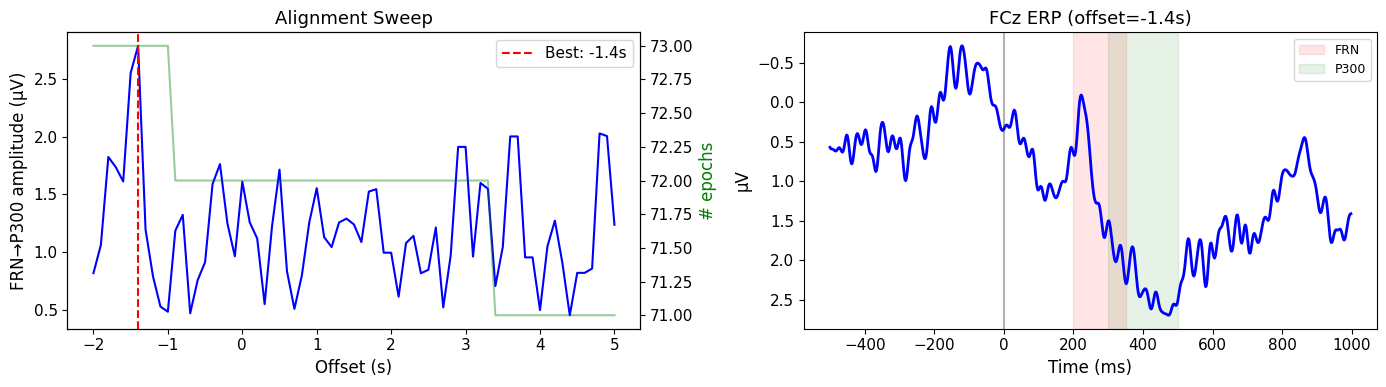


→ Using offset = -1.4s for all subsequent analyses


In [16]:
def epoch_at_offset(eeg, srate, event_times_sec, offset_sec, tmin, tmax, reject_uv=200):
    """Extract epochs with a timing offset applied to event times."""
    n_pre = int(round(abs(tmin) * srate))
    n_post = int(round(tmax * srate))
    n_epoch = n_pre + n_post
    times = np.arange(n_epoch) / srate + tmin
    epochs, kept_idx = [], []
    for i, t in enumerate(event_times_sec):
        center = int(round((t + offset_sec) * srate))
        s0, s1 = center - n_pre, center + n_post
        if s0 < 0 or s1 > len(eeg):
            continue
        ep = eeg[s0:s1]
        if ep.shape[0] != n_epoch:
            continue
        if np.max(np.abs(ep)) > reject_uv:
            continue
        epochs.append(ep)
        kept_idx.append(i)
    if not epochs:
        return np.empty((0, n_epoch, eeg.shape[1])), times, kept_idx
    return np.stack(epochs), times, kept_idx

# ── Sweep offsets ──
offsets = np.arange(-2.0, 5.01, 0.1)
fcz_idx = ch_names.index('FCz')
feedback_times = bdf['feedback_onset'].values

frn_scores = []
n_epochs_per_offset = []

for off in offsets:
    epochs, times, kept = epoch_at_offset(
        eeg_clean, SRATE, feedback_times, off, -0.5, 1.0, reject_uv=300
    )
    n_epochs_per_offset.append(len(kept))
    if len(kept) < 10:
        frn_scores.append(0)
        continue
    erp = np.mean(epochs[:, :, fcz_idx], axis=0)
    bl_mask = (times >= -0.3) & (times <= -0.05)
    erp -= np.mean(erp[bl_mask])
    frn_mask = (times >= 0.2) & (times <= 0.35)
    p3_mask = (times >= 0.3) & (times <= 0.5)
    frn_amp = np.min(erp[frn_mask])
    p3_amp = np.max(erp[p3_mask])
    frn_scores.append(p3_amp - frn_amp)

frn_scores = np.array(frn_scores)
best_offset_idx = np.argmax(frn_scores)
BEST_OFFSET = offsets[best_offset_idx]

print(f"Best alignment offset: {BEST_OFFSET:.1f} s")
print(f"  FRN/P300 score: {frn_scores[best_offset_idx]:.2f} µV")
print(f"  Epochs retained: {n_epochs_per_offset[best_offset_idx]}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(offsets, frn_scores, 'b-', linewidth=1.5)
ax1.axvline(BEST_OFFSET, color='red', linestyle='--', label=f'Best: {BEST_OFFSET:.1f}s')
ax1.set_xlabel('Offset (s)'); ax1.set_ylabel('FRN→P300 amplitude (µV)')
ax1.set_title('Alignment Sweep'); ax1.legend()
ax1b = ax1.twinx()
ax1b.plot(offsets, n_epochs_per_offset, 'g-', alpha=0.4); ax1b.set_ylabel('# epochs', color='green')

epochs_best, times_best, _ = epoch_at_offset(eeg_clean, SRATE, feedback_times, BEST_OFFSET, -0.5, 1.0, reject_uv=300)
erp_best = np.mean(epochs_best[:, :, fcz_idx], axis=0)
bl = (times_best >= -0.3) & (times_best <= -0.05)
erp_best -= np.mean(erp_best[bl])
ax2.plot(times_best*1000, erp_best, 'b-', linewidth=2)
ax2.axvline(0, color='black', alpha=0.3); ax2.axvspan(200, 350, alpha=0.1, color='red', label='FRN')
ax2.axvspan(300, 500, alpha=0.1, color='green', label='P300')
ax2.set_xlabel('Time (ms)'); ax2.set_ylabel('µV'); ax2.set_title(f'FCz ERP (offset={BEST_OFFSET:.1f}s)')
ax2.legend(fontsize=9); ax2.invert_yaxis()
fig.tight_layout(); plt.show()
print(f"\n→ Using offset = {BEST_OFFSET:.1f}s for all subsequent analyses")


## Step 4: Extract Feedback & Decision Epochs

Feedback epochs: 71 (rejected: 3)
  Win: 40,  Loss: 31
Decision epochs (response-locked): 71 (rejected: 3)


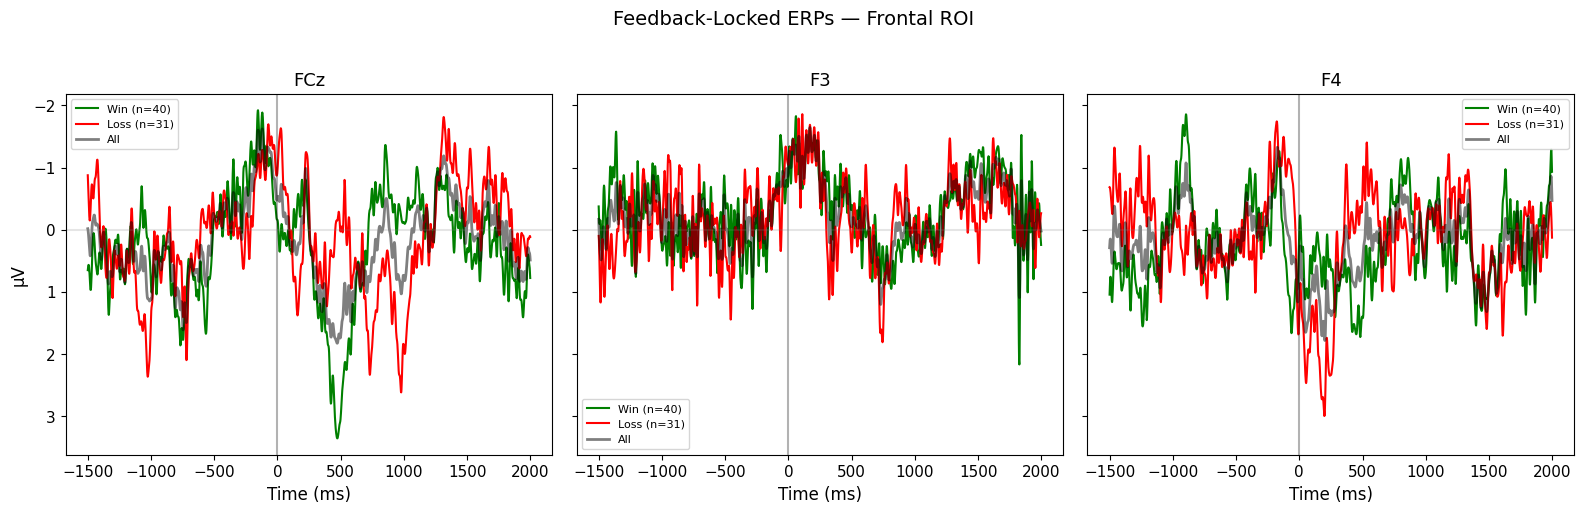

In [19]:
# ── Feedback-locked epochs ──
epochs_fb, times_fb, kept_fb = epoch_at_offset(
    eeg_clean, SRATE, feedback_times, BEST_OFFSET,
    EPOCH_TMIN, EPOCH_TMAX, reject_uv=EPOCH_REJECT_UV
)
reward_flags = bdf['reward'].values[kept_fb]
ep_win = epochs_fb[reward_flags]
ep_loss = epochs_fb[~reward_flags]

print(f"Feedback epochs: {len(epochs_fb)} (rejected: {len(bdf) - len(kept_fb)})")
print(f"  Win: {len(ep_win)},  Loss: {len(ep_loss)}")

# ── Decision-locked epochs (locked to response) ──
response_times = bdf['response_time'].values
epochs_dec, times_dec, kept_dec = epoch_at_offset(
    eeg_clean, SRATE, response_times, BEST_OFFSET,
    -1.5, 0.5, reject_uv=EPOCH_REJECT_UV
)
print(f"Decision epochs (response-locked): {len(epochs_dec)} (rejected: {len(bdf) - len(kept_dec)})")

# ── Verify alignment: feedback ERPs ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
frontal_idx = [ch_names.index(c) for c in FRONTAL_ROI if c in ch_names]

for ax, ci in zip(axes, frontal_idx):
    bl = (times_fb >= BASELINE_WIN[0]) & (times_fb <= BASELINE_WIN[1])
    erp_w = np.mean(ep_win[:, :, ci], axis=0); erp_w -= np.mean(erp_w[bl])
    erp_l = np.mean(ep_loss[:, :, ci], axis=0); erp_l -= np.mean(erp_l[bl])
    erp_a = np.mean(epochs_fb[:, :, ci], axis=0); erp_a -= np.mean(erp_a[bl])
    ax.plot(times_fb*1000, erp_w, 'g-', lw=1.5, label=f'Win (n={len(ep_win)})')
    ax.plot(times_fb*1000, erp_l, 'r-', lw=1.5, label=f'Loss (n={len(ep_loss)})')
    ax.plot(times_fb*1000, erp_a, 'k-', lw=2, alpha=0.5, label='All')
    ax.axvline(0, color='black', alpha=0.3); ax.axhline(0, color='gray', alpha=0.2)
    ax.set_xlabel('Time (ms)'); ax.set_title(ch_names[ci]); ax.legend(fontsize=8)
    ax.invert_yaxis()
axes[0].set_ylabel('µV')
fig.suptitle('Feedback-Locked ERPs — Frontal ROI', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## Step 5: Shared Analysis Functions

In [22]:
def morlet_tfr(epochs, srate, freqs, n_cycles=5, ch_idx=None):
    """Compute time-frequency power via Morlet wavelets."""
    n_ep, n_times, n_ch = epochs.shape
    if ch_idx is None:
        ch_idx = list(range(n_ch))
    power = np.zeros((len(freqs), n_times))
    for fi, f in enumerate(freqs):
        sigma_t = n_cycles / (2 * np.pi * f)
        hw = int(np.ceil(3.5 * sigma_t * srate))
        t_wav = np.arange(-hw, hw+1) / srate
        wav = np.exp(2j*np.pi*f*t_wav) * np.exp(-t_wav**2 / (2*sigma_t**2))
        wav /= np.sqrt(np.sum(np.abs(wav)**2))
        for ci in ch_idx:
            for ei in range(n_ep):
                analytic = signal.fftconvolve(epochs[ei, :, ci], wav, mode='same')
                power[fi] += np.abs(analytic)**2
        power[fi] /= (n_ep * len(ch_idx))
    return power

def find_band_peak(freqs, spectrum, band, smooth_sigma=1.0):
    """Find peak frequency within a band from a 1D spectrum."""
    mask = (freqs >= band[0]) & (freqs <= band[1])
    bf, bs = freqs[mask], spectrum[mask]
    if len(bf) == 0:
        return None, None, None
    if smooth_sigma > 0:
        bs_smooth = gaussian_filter1d(bs, sigma=smooth_sigma)
    else:
        bs_smooth = bs
    peak_idx = np.argmax(bs_smooth)
    edge = peak_idx in {0, len(bf) - 1}
    return float(bf[peak_idx]), float(bs_smooth[peak_idx]), edge

def specparam_band_peak(freqs, psd, band, freq_range=(2, 40)):
    """Run specparam and extract the strongest peak within a band."""
    if not SPECPARAM_AVAILABLE:
        return None, None
    sm = SpectralModel(peak_width_limits=[1.0, 8.0], max_n_peaks=6,
                       min_peak_height=0.05, aperiodic_mode='fixed')
    sm.fit(freqs, psd, freq_range=list(freq_range))
    pk = sm.results.params.periodic.params
    best_cf, best_pw = None, 0
    if pk.size > 0 and pk.ndim == 2:
        for p in pk:
            if band[0] <= p[0] <= band[1] and p[1] > best_pw:
                best_cf, best_pw = p[0], p[1]
    return (float(best_cf) if best_cf else None, sm)

print("Utility functions defined.")


Utility functions defined.


## Step 6: Theta Estimation (Feedback-Locked)

**Primary method:** Task-locked power peak at frontal ROI during the feedback window (Bjekić et al., 2022). Morlet wavelet TFR → baseline-corrected → peak frequency in 4–8 Hz.

**Validation:** Specparam on the feedback-window PSD to confirm the peak is a genuine oscillation above the aperiodic background (Donoghue et al., 2020).

**Supplementary:** PLV between frontal and posterior channels (Reinhart & Nguyen, 2019), retained as a connectivity metric.


In [25]:
# ── TFR for theta ──
tfr_freqs = np.arange(2.0, 15.25, 0.25)
frontal_ch_idx = [ch_names.index(c) for c in FRONTAL_ROI if ch_names.index(c) not in BAD_CH_IDX]

print(f"Computing feedback-locked TFR ({len(tfr_freqs)} freqs × {len(epochs_fb)} epochs)...", end=' ')
t0 = time.time()
tfr_fb = morlet_tfr(epochs_fb, SRATE, tfr_freqs, n_cycles=5, ch_idx=frontal_ch_idx)
print(f"done ({time.time()-t0:.1f}s)")

# Baseline correction (dB)
bl_mask_t = (times_fb >= BASELINE_WIN[0]) & (times_fb <= BASELINE_WIN[1])
baseline = np.mean(tfr_fb[:, bl_mask_t], axis=1, keepdims=True)
baseline = np.maximum(baseline, 1e-30)
tfr_fb_db = 10 * np.log10(np.maximum(tfr_fb, 1e-30) / baseline)

# Extract theta spectrum in feedback window
fb_win_t = (times_fb >= FEEDBACK_WIN[0]) & (times_fb <= FEEDBACK_WIN[1])
theta_mask_f = (tfr_freqs >= BANDS['theta'][0]) & (tfr_freqs <= BANDS['theta'][1])
theta_spectrum = np.mean(tfr_fb_db[theta_mask_f][:, fb_win_t], axis=1)
theta_freqs_tfr = tfr_freqs[theta_mask_f]

ITF_POWER, itf_pow_val, itf_edge = find_band_peak(theta_freqs_tfr, theta_spectrum, BANDS['theta'])
print(f"  Power-based iTF: {ITF_POWER:.2f} Hz ({itf_pow_val:.2f} dB, edge={'⚠' if itf_edge else '✓'})")

# ── Specparam on feedback-window PSD ──
win_mask = (times_fb >= FEEDBACK_WIN[0]) & (times_fb <= FEEDBACK_WIN[1])
frontal_fb_win = epochs_fb[:, win_mask][:, :, frontal_ch_idx]
frontal_mean = np.mean(frontal_fb_win, axis=2)
nperseg = min(int(SRATE * 0.5), frontal_mean.shape[1])
psds = [signal.welch(frontal_mean[ei], fs=SRATE, nperseg=nperseg,
                     noverlap=nperseg//2, window='hann')[1]
        for ei in range(len(frontal_mean))]
f_welch = signal.welch(frontal_mean[0], fs=SRATE, nperseg=nperseg,
                       noverlap=nperseg//2, window='hann')[0]
avg_psd = np.mean(psds, axis=0)

ITF_SPECPARAM, sm_theta = specparam_band_peak(f_welch, avg_psd, BANDS['theta'])
if ITF_SPECPARAM:
    print(f"  Specparam iTF: {ITF_SPECPARAM:.2f} Hz")
else:
    print(f"  Specparam: no theta peak detected")

# ── PLV (supplementary) ──
def compute_plv_spectrum(epochs, srate, ch_a, ch_b, times, win, freqs, bw=1.0):
    win_mask = (times >= win[0]) & (times <= win[1])
    n_ep = len(epochs); nyq = srate / 2.0
    plv_spec = np.zeros(len(freqs))
    for fi, fc in enumerate(freqs):
        lo, hi = max(fc-bw/2, 0.5), min(fc+bw/2, nyq-1)
        if lo >= hi: continue
        b, a = signal.butter(3, [lo/nyq, hi/nyq], btype='band')
        pair_plvs = []
        for ci_a in ch_a:
            for ci_b in ch_b:
                pa = np.zeros((n_ep, win_mask.sum()))
                pb = np.zeros((n_ep, win_mask.sum()))
                for ei in range(n_ep):
                    pa[ei] = np.angle(signal.hilbert(signal.filtfilt(b, a, epochs[ei, :, ci_a]))[win_mask])
                    pb[ei] = np.angle(signal.hilbert(signal.filtfilt(b, a, epochs[ei, :, ci_b]))[win_mask])
                plv = np.abs(np.mean(np.exp(1j*(pa-pb)), axis=0))
                pair_plvs.append(np.mean(plv))
        plv_spec[fi] = np.mean(pair_plvs)
    return plv_spec

theta_freqs_plv = np.arange(BANDS['theta'][0], BANDS['theta'][1]+THETA_STEP/2, THETA_STEP)
posterior_ch_idx = [ch_names.index(c) for c in POSTERIOR_ROI if ch_names.index(c) not in BAD_CH_IDX]

print(f"Computing theta PLV...", end=' '); t0 = time.time()
plv_theta = compute_plv_spectrum(epochs_fb, SRATE, frontal_ch_idx, posterior_ch_idx,
                                  times_fb, FEEDBACK_WIN, theta_freqs_plv)
print(f"done ({time.time()-t0:.1f}s)")
ITF_PLV = theta_freqs_plv[np.argmax(plv_theta)]
print(f"  PLV-based iTF: {ITF_PLV:.2f} Hz (PLV={plv_theta.max():.4f})")


Computing feedback-locked TFR (53 freqs × 71 epochs)... done (0.9s)
  Power-based iTF: 5.00 Hz (-0.24 dB, edge=✓)

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

  Specparam: no theta peak detected
Computing theta PLV... done (2.9s)
  PLV-based iTF: 7.50 Hz (PLV=0.2965)


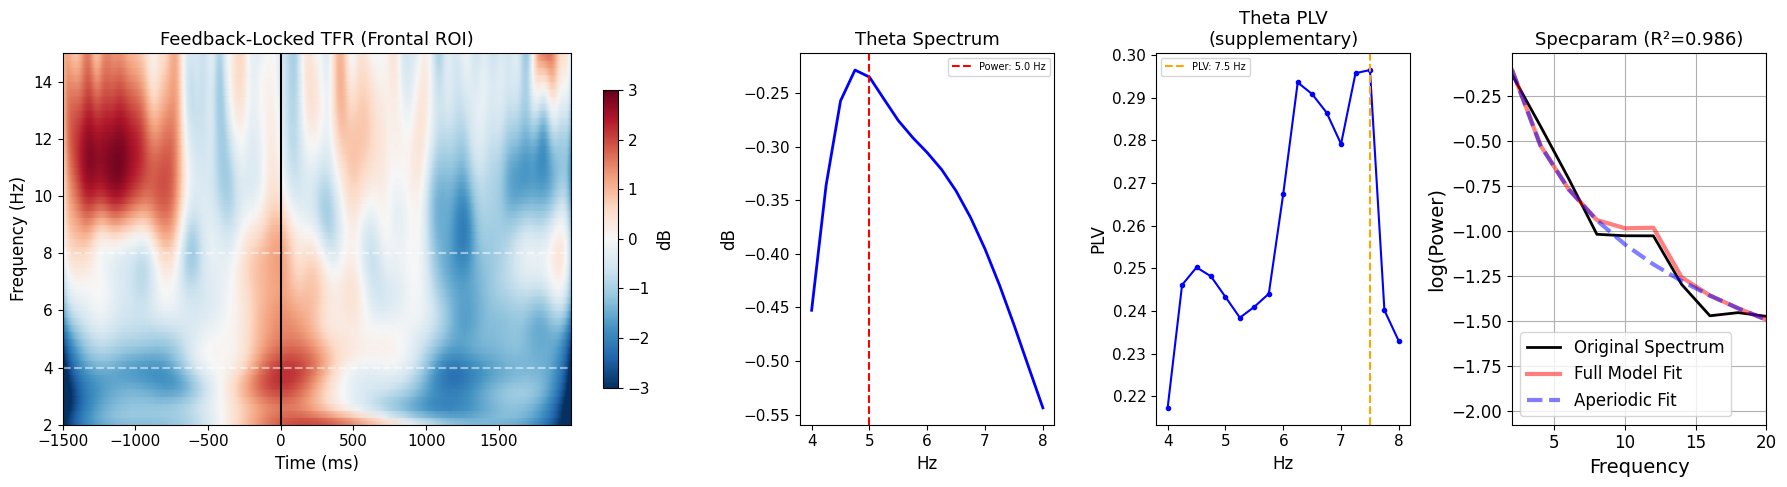

In [27]:
fig = plt.figure(figsize=(18, 5))
gs = GridSpec(1, 4, width_ratios=[2.5, 1, 1, 1])

# TFR heatmap
ax1 = fig.add_subplot(gs[0])
im = ax1.pcolormesh(times_fb*1000, tfr_freqs, tfr_fb_db, shading='gouraud',
                     cmap='RdBu_r', vmin=-3, vmax=3)
ax1.axvline(0, color='black', lw=1.5)
ax1.axhline(BANDS['theta'][0], color='white', ls='--', alpha=0.5)
ax1.axhline(BANDS['theta'][1], color='white', ls='--', alpha=0.5)
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Feedback-Locked TFR (Frontal ROI)')
fig.colorbar(im, ax=ax1, label='dB', shrink=0.8)

# Theta power spectrum
ax2 = fig.add_subplot(gs[1])
ax2.plot(theta_freqs_tfr, theta_spectrum, 'b-', lw=2)
ax2.axvline(ITF_POWER, color='red', ls='--', label=f'Power: {ITF_POWER:.1f} Hz')
if ITF_SPECPARAM: ax2.axvline(ITF_SPECPARAM, color='purple', ls=':', label=f'Specparam: {ITF_SPECPARAM:.1f}')
ax2.set_xlabel('Hz'); ax2.set_ylabel('dB'); ax2.set_title('Theta Spectrum'); ax2.legend(fontsize=7)

# PLV spectrum
ax3 = fig.add_subplot(gs[2])
ax3.plot(theta_freqs_plv, plv_theta, 'b-o', ms=3, lw=1.5)
ax3.axvline(ITF_PLV, color='orange', ls='--', label=f'PLV: {ITF_PLV:.1f} Hz')
ax3.set_xlabel('Hz'); ax3.set_ylabel('PLV'); ax3.set_title('Theta PLV\n(supplementary)'); ax3.legend(fontsize=7)

# Specparam model fit
ax4 = fig.add_subplot(gs[3])
if sm_theta:
    sm_theta.plot(ax=ax4, plt_log=False)
    r2 = sm_theta.results.metrics.results['gof_rsquared']
    ax4.set_title(f'Specparam (R²={r2:.3f})'); ax4.set_xlim(2, 20)
else:
    ax4.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax4.transAxes)

fig.tight_layout(); plt.show()


## Step 7: Beta Estimation (Decision- and Feedback-Locked)

Beta oscillations are relevant to your bandit task at two time points:

1. **Pre-response (decision phase):** Beta suppression (ERD) indexes the effort/conflict of the decision. Greater suppression accompanies exploratory choices in probabilistic tasks (Sporn et al., 2023, *Cerebral Cortex*).

2. **Post-feedback:** Frontal beta synchronization (ERS) after reward reflects policy maintenance and information transfer (Holroyd et al., 2020, *Scientific Reports*).

We estimate individualized beta frequency from both windows.


In [30]:
# ── Beta from feedback-locked TFR (already computed) ──
beta_mask_f = (tfr_freqs >= BANDS['beta'][0]) & (tfr_freqs <= BANDS['beta'][1])
beta_spectrum_fb = np.mean(tfr_fb_db[beta_mask_f][:, fb_win_t], axis=1)
beta_freqs = tfr_freqs[beta_mask_f]

IBF_FB, ibf_fb_val, ibf_fb_edge = find_band_peak(beta_freqs, beta_spectrum_fb, BANDS['beta'])
print(f"Feedback beta peak: {IBF_FB:.2f} Hz ({ibf_fb_val:.2f} dB, edge={'⚠' if ibf_fb_edge else '✓'})")

# ── Beta from decision-locked TFR ──
dec_freqs = np.arange(8.0, 35.25, 0.5)
dec_ch_idx = frontal_ch_idx  # same frontal ROI

print(f"Computing decision-locked TFR ({len(dec_freqs)} freqs × {len(epochs_dec)} epochs)...", end=' ')
t0 = time.time()
tfr_dec = morlet_tfr(epochs_dec, SRATE, dec_freqs, n_cycles=5, ch_idx=dec_ch_idx)
print(f"done ({time.time()-t0:.1f}s)")

# Baseline: -1.5 to -1.0s before response (early decision period)
bl_dec = (times_dec >= -1.5) & (times_dec <= -1.0)
bl_dec_pw = np.mean(tfr_dec[:, bl_dec], axis=1, keepdims=True)
bl_dec_pw = np.maximum(bl_dec_pw, 1e-30)
tfr_dec_db = 10 * np.log10(np.maximum(tfr_dec, 1e-30) / bl_dec_pw)

# Pre-response beta spectrum (-1.0 to -0.1s before response)
pre_resp_t = (times_dec >= DECISION_PRE_RESP[0]) & (times_dec <= DECISION_PRE_RESP[1])
beta_dec_mask = (dec_freqs >= BANDS['beta'][0]) & (dec_freqs <= BANDS['beta'][1])
beta_spectrum_dec = np.mean(tfr_dec_db[beta_dec_mask][:, pre_resp_t], axis=1)
beta_freqs_dec = dec_freqs[beta_dec_mask]

IBF_DEC, ibf_dec_val, ibf_dec_edge = find_band_peak(beta_freqs_dec, beta_spectrum_dec, BANDS['beta'])
# For decision beta, we actually want the frequency of maximum SUPPRESSION (ERD)
# i.e., most negative dB value
erd_idx = np.argmin(gaussian_filter1d(beta_spectrum_dec, sigma=1.0))
IBF_DEC_ERD = float(beta_freqs_dec[erd_idx])
print(f"Decision beta ERD peak: {IBF_DEC_ERD:.2f} Hz ({beta_spectrum_dec[erd_idx]:.2f} dB)")

# ── Specparam on feedback beta ──
IBF_SPECPARAM, sm_beta = specparam_band_peak(f_welch, avg_psd, BANDS['beta'])
if IBF_SPECPARAM:
    print(f"Specparam beta: {IBF_SPECPARAM:.2f} Hz")
else:
    print(f"Specparam: no beta peak detected")


Feedback beta peak: 13.00 Hz (0.03 dB, edge=⚠)
Computing decision-locked TFR (55 freqs × 71 epochs)... done (0.6s)
Decision beta ERD peak: 22.50 Hz (0.21 dB)

	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Specparam: no beta peak detected


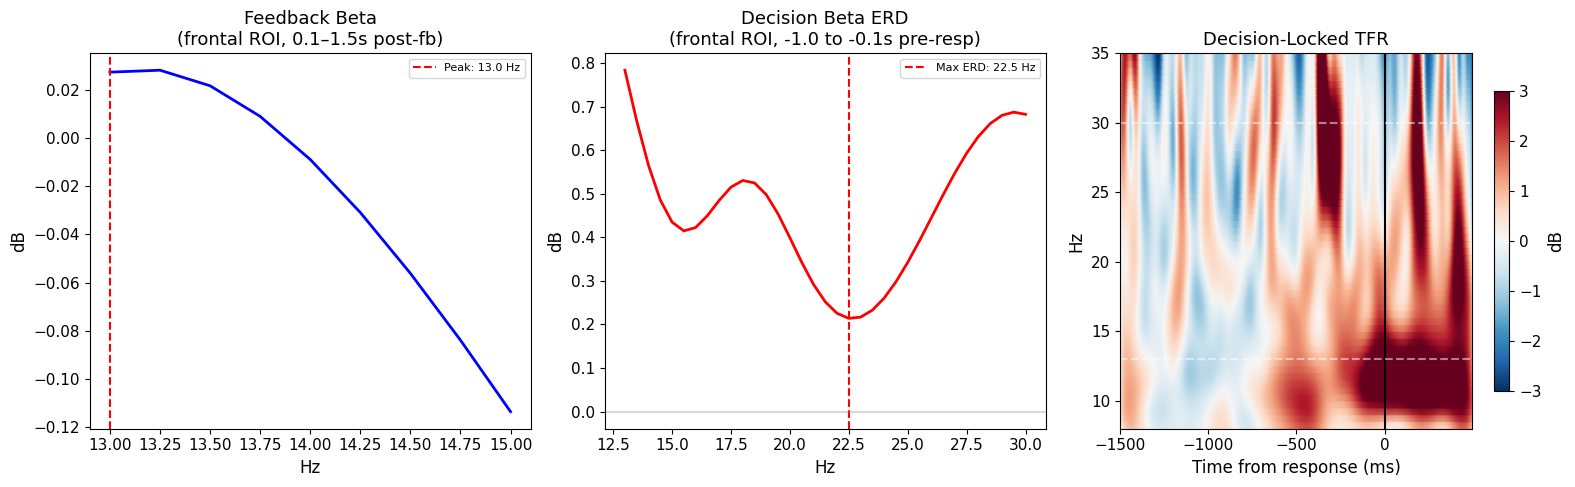

In [32]:
# Visualize beta
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Feedback beta spectrum
ax = axes[0]
ax.plot(beta_freqs, beta_spectrum_fb, 'b-', lw=2)
ax.axvline(IBF_FB, color='red', ls='--', label=f'Peak: {IBF_FB:.1f} Hz')
if IBF_SPECPARAM: ax.axvline(IBF_SPECPARAM, color='purple', ls=':', label=f'Specparam: {IBF_SPECPARAM:.1f}')
ax.set_xlabel('Hz'); ax.set_ylabel('dB'); ax.set_title('Feedback Beta\n(frontal ROI, 0.1–1.5s post-fb)')
ax.legend(fontsize=8)

# Decision beta spectrum (ERD)
ax = axes[1]
ax.plot(beta_freqs_dec, beta_spectrum_dec, 'r-', lw=2)
ax.axvline(IBF_DEC_ERD, color='red', ls='--', label=f'Max ERD: {IBF_DEC_ERD:.1f} Hz')
ax.axhline(0, color='gray', alpha=0.3)
ax.set_xlabel('Hz'); ax.set_ylabel('dB'); ax.set_title('Decision Beta ERD\n(frontal ROI, -1.0 to -0.1s pre-resp)')
ax.legend(fontsize=8)

# Decision-locked TFR
ax = axes[2]
im = ax.pcolormesh(times_dec*1000, dec_freqs, tfr_dec_db, shading='gouraud',
                    cmap='RdBu_r', vmin=-3, vmax=3)
ax.axvline(0, color='black', lw=1.5, label='Response')
ax.axhline(BANDS['beta'][0], color='white', ls='--', alpha=0.5)
ax.axhline(BANDS['beta'][1], color='white', ls='--', alpha=0.5)
ax.set_xlabel('Time from response (ms)'); ax.set_ylabel('Hz')
ax.set_title('Decision-Locked TFR')
fig.colorbar(im, ax=ax, label='dB', shrink=0.8)

fig.tight_layout(); plt.show()


## Step 8: Alpha Estimation (Continuous / Resting)

Alpha is estimated from the **continuous PSD** (not task-locked), since the individual alpha frequency (IAF) is a stable trait-like measure best captured from resting or inter-trial periods. Posterior channels (P3, P4) provide the clearest alpha peak.

IAF also serves as an anchor for ITF estimation via the Klimesch (1999) method: ITF ≈ IAF − 5 Hz. This provides a third, independent theta estimate for cross-referencing.


IAF (posterior PSD peak): 11.00 Hz (edge=✓)
IAF (specparam): 11.27 Hz
Klimesch ITF (IAF − 5): 6.27 Hz


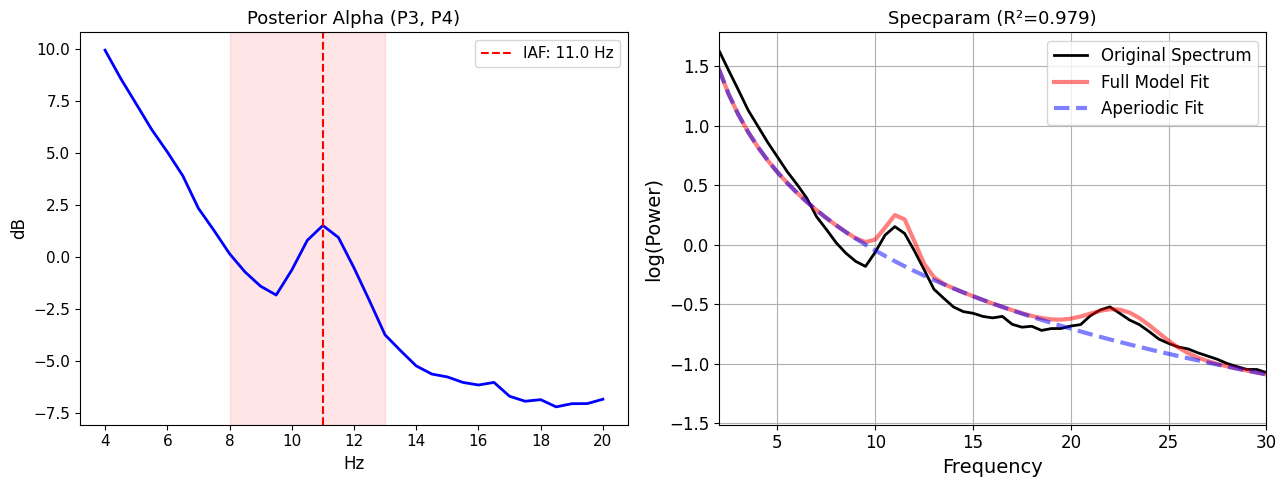

In [35]:
# Continuous Welch PSD at posterior channels
posterior_idx = [ch_names.index(c) for c in POSTERIOR_ALPHA_ROI if ch_names.index(c) not in BAD_CH_IDX]
freqs_c, psd_c = signal.welch(eeg_clean, fs=SRATE, nperseg=2*SRATE, noverlap=SRATE, axis=0)
psd_posterior = np.mean(psd_c[:, posterior_idx], axis=1)

# Peak detection
IAF_POWER, iaf_val, iaf_edge = find_band_peak(freqs_c, 10*np.log10(np.maximum(psd_posterior, 1e-30)),
                                                BANDS['alpha'])
print(f"IAF (posterior PSD peak): {IAF_POWER:.2f} Hz (edge={'⚠' if iaf_edge else '✓'})")

# Specparam
IAF_SPECPARAM, sm_alpha = specparam_band_peak(freqs_c, psd_posterior, BANDS['alpha'])
if IAF_SPECPARAM:
    print(f"IAF (specparam): {IAF_SPECPARAM:.2f} Hz")

# Klimesch-derived theta estimate
ITF_KLIMESCH = (IAF_SPECPARAM or IAF_POWER) - 5.0
ITF_KLIMESCH = max(BANDS['theta'][0], min(BANDS['theta'][1], ITF_KLIMESCH))
print(f"Klimesch ITF (IAF − 5): {ITF_KLIMESCH:.2f} Hz")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
f_mask = (freqs_c >= 4) & (freqs_c <= 20)
ax1.plot(freqs_c[f_mask], 10*np.log10(np.maximum(psd_posterior[f_mask], 1e-30)), 'b-', lw=2)
ax1.axvline(IAF_POWER, color='red', ls='--', label=f'IAF: {IAF_POWER:.1f} Hz')
ax1.axvspan(*BANDS['alpha'], alpha=0.1, color='red')
ax1.set_xlabel('Hz'); ax1.set_ylabel('dB'); ax1.set_title('Posterior Alpha (P3, P4)')
ax1.legend()

if sm_alpha:
    sm_alpha.plot(ax=ax2, plt_log=False)
    r2 = sm_alpha.results.metrics.results['gof_rsquared']
    ax2.set_title(f'Specparam (R²={r2:.3f})'); ax2.set_xlim(2, 30)
fig.tight_layout(); plt.show()


## Step 9: Theta-Gamma Phase-Amplitude Coupling (Exploratory)

Theta-gamma PAC is computed as a participant-level summary metric during the feedback window at frontal electrodes. This is **not** used for frequency selection — it's a baseline coupling strength measure that could moderate tACS response (deficiency compensation hypothesis: weaker endogenous coupling → more room for tACS to help).

We use the Tort et al. (2010) modulation index, with theta phase (4–8 Hz) and low-gamma/high-beta amplitude (25–45 Hz, the range accessible with our 500 Hz sampling rate and 7-electrode setup).

**Caveat:** Surface EEG gamma is noisy with this few electrodes. Treat this as exploratory.


Computing theta-gamma PAC at frontal ROI... done (0.1s)
  Modulation Index: 0.000023
  (Higher = stronger theta-gamma coupling during feedback)


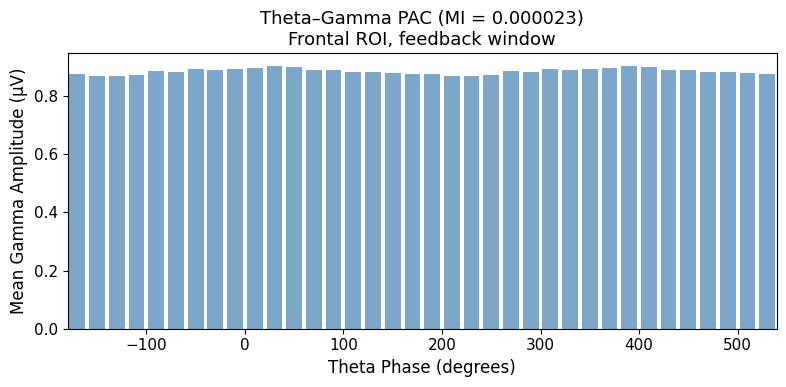

In [38]:
def compute_pac_mi(epochs, srate, ch_idx, times, win,
                   phase_band=(4, 8), amp_band=(25, 45), n_bins=18):
    """
    Compute phase-amplitude coupling using the Tort modulation index.
    
    Returns
    -------
    mi : float, modulation index (higher = stronger coupling)
    phase_amp_dist : array, mean amplitude per phase bin
    """
    win_mask = (times >= win[0]) & (times <= win[1])
    nyq = srate / 2.0
    
    # Bandpass for phase and amplitude
    bp, ap = signal.butter(3, [phase_band[0]/nyq, phase_band[1]/nyq], btype='band')
    ba, aa = signal.butter(3, [amp_band[0]/nyq, amp_band[1]/nyq], btype='band')
    
    # Collect phase-amplitude pairs across all epochs and channels
    all_phase = []
    all_amp = []
    
    for ei in range(len(epochs)):
        for ci in ch_idx:
            sig = epochs[ei, :, ci]
            phase_sig = signal.filtfilt(bp, ap, sig)
            amp_sig = signal.filtfilt(ba, aa, sig)
            
            phase = np.angle(signal.hilbert(phase_sig))[win_mask]
            amp = np.abs(signal.hilbert(amp_sig))[win_mask]
            
            all_phase.append(phase)
            all_amp.append(amp)
    
    all_phase = np.concatenate(all_phase)
    all_amp = np.concatenate(all_amp)
    
    # Bin amplitudes by phase (Tort method)
    phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    mean_amp = np.zeros(n_bins)
    for bi in range(n_bins):
        mask = (all_phase >= phase_bins[bi]) & (all_phase < phase_bins[bi+1])
        if mask.sum() > 0:
            mean_amp[bi] = np.mean(all_amp[mask])
    
    # Normalize to probability distribution
    mean_amp_norm = mean_amp / (mean_amp.sum() + 1e-30)
    
    # Modulation index = KL divergence from uniform / log(n_bins)
    uniform = np.ones(n_bins) / n_bins
    # KL divergence (with smoothing to avoid log(0))
    mean_amp_smooth = mean_amp_norm + 1e-12
    mean_amp_smooth /= mean_amp_smooth.sum()
    kl = np.sum(mean_amp_smooth * np.log(mean_amp_smooth / uniform))
    mi = kl / np.log(n_bins)
    
    return mi, mean_amp, phase_bins

# Compute PAC
print("Computing theta-gamma PAC at frontal ROI...", end=' ')
t0 = time.time()
pac_mi, pac_dist, pac_bins = compute_pac_mi(
    epochs_fb, SRATE, frontal_ch_idx, times_fb, FEEDBACK_WIN,
    phase_band=BANDS['theta'], amp_band=(25, 45)
)
print(f"done ({time.time()-t0:.1f}s)")
print(f"  Modulation Index: {pac_mi:.6f}")
print(f"  (Higher = stronger theta-gamma coupling during feedback)")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bin_centers = (pac_bins[:-1] + pac_bins[1:]) / 2
# Plot two cycles for visual clarity
ax.bar(np.degrees(np.concatenate([bin_centers, bin_centers + 2*np.pi])),
       np.concatenate([pac_dist, pac_dist]),
       width=360/len(bin_centers) * 0.8, color='steelblue', alpha=0.7)
ax.set_xlabel('Theta Phase (degrees)')
ax.set_ylabel('Mean Gamma Amplitude (µV)')
ax.set_title(f'Theta–Gamma PAC (MI = {pac_mi:.6f})\nFrontal ROI, feedback window')
ax.set_xlim(-180, 540)
fig.tight_layout(); plt.show()


## Step 10: Consolidated Frequency Estimates

Decision logic (per band):
1. **Power-based peak** from task-locked TFR (primary, following Bjekić et al., 2022)
2. **Specparam peak** from feedback-window PSD (validation, Donoghue et al., 2020)
3. Agreement within 1 Hz → HIGH confidence; 1–2 Hz → MODERATE; >2 Hz or single method → LOW
4. Round to 0.5 Hz (Reinhart & Nguyen, 2019 convention)
5. PLV retained as supplementary metric, not used in frequency selection


In [41]:
def decide_frequency(power_hz, specparam_hz, band, fallback, label,
                     plv_hz=None, klimesch_hz=None):
    """Cross-reference estimates and return (recommended_hz, confidence, details)."""
    estimates = {'Power (TFR)': power_hz, 'Specparam': specparam_hz}
    if klimesch_hz is not None:
        estimates['Klimesch (IAF−5)'] = klimesch_hz
    
    valid = {k: v for k, v in estimates.items() if v is not None}
    
    if len(valid) >= 2:
        vals = list(valid.values())
        spread = max(vals) - min(vals)
        if spread <= 1.0:
            rec = np.mean(vals)
            conf = "HIGH"
        elif spread <= 2.0:
            rec = valid.get('Power (TFR)', np.mean(vals))
            conf = "MODERATE"
        else:
            rec = valid.get('Power (TFR)', fallback)
            conf = "LOW"
    elif len(valid) == 1:
        rec = list(valid.values())[0]
        conf = "LOW (single estimate)"
    else:
        rec = fallback
        conf = "NONE — fallback"
    
    rec = np.round(rec * 2) / 2  # 0.5 Hz resolution
    rec = max(band[0], min(band[1], rec))
    
    details = {k: v for k, v in estimates.items()}
    if plv_hz is not None:
        details['PLV (supplementary)'] = plv_hz
    
    return float(rec), conf, details

# ── Theta ──
theta_rec, theta_conf, theta_details = decide_frequency(
    ITF_POWER, ITF_SPECPARAM, BANDS['theta'], 6.0, 'Theta',
    plv_hz=ITF_PLV, klimesch_hz=ITF_KLIMESCH
)

# ── Beta (feedback) ──
beta_rec, beta_conf, beta_details = decide_frequency(
    IBF_FB, IBF_SPECPARAM, BANDS['beta'], 20.0, 'Beta'
)
beta_details['Decision ERD'] = IBF_DEC_ERD

# ── Alpha ──
alpha_rec, alpha_conf, alpha_details = decide_frequency(
    IAF_POWER, IAF_SPECPARAM, BANDS['alpha'], 10.0, 'Alpha'
)

# Frequency match metric
freq_match = abs(theta_rec - STIM_FREQ_HZ)

# ── Print ──
print("╔═══════════════════════════════════════════════════════════════════════╗")
print("║              INDIVIDUALIZED FREQUENCY ESTIMATES                     ║")
print("╠═══════════════════════════════════════════════════════════════════════╣")

for band_name, rec, conf, details in [
    ('THETA (4–8 Hz)', theta_rec, theta_conf, theta_details),
    ('BETA (13–30 Hz)', beta_rec, beta_conf, beta_details),
    ('ALPHA (8–13 Hz)', alpha_rec, alpha_conf, alpha_details),
]:
    print(f"║                                                                     ║")
    print(f"║  {band_name}".ljust(72) + "║")
    print(f"║  {'─'*67}  ║")
    for method, val in details.items():
        if val is not None:
            print(f"║    {method}: {val:.2f} Hz".ljust(72) + "║")
        else:
            print(f"║    {method}: no peak".ljust(72) + "║")
    print(f"║    ▶ RECOMMENDED: {rec:.1f} Hz  [{conf}]".ljust(72) + "║")

print(f"║                                                                     ║")
print(f"║  THETA–GAMMA PAC".ljust(72) + "║")
print(f"║  {'─'*67}  ║")
print(f"║    Modulation Index: {pac_mi:.6f}  (exploratory)".ljust(72) + "║")
print(f"║                                                                     ║")
print(f"║  FREQUENCY MATCH".ljust(72) + "║")
print(f"║  {'─'*67}  ║")
print(f"║    |iTF − stim| = |{theta_rec:.1f} − {STIM_FREQ_HZ:.1f}| = {freq_match:.1f} Hz".ljust(72) + "║")
print("╚═══════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════╗
║              INDIVIDUALIZED FREQUENCY ESTIMATES                     ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                     ║
║  THETA (4–8 Hz)                                                       ║
║  ───────────────────────────────────────────────────────────────────  ║
║    Power (TFR): 5.00 Hz                                               ║
║    Specparam: no peak                                                 ║
║    Klimesch (IAF−5): 6.27 Hz                                          ║
║    PLV (supplementary): 7.50 Hz                                       ║
║    ▶ RECOMMENDED: 5.0 Hz  [MODERATE]                                  ║
║                                                                     ║
║  BETA (13–30 Hz)                                                      ║
║  ─────────────────────────────────────────

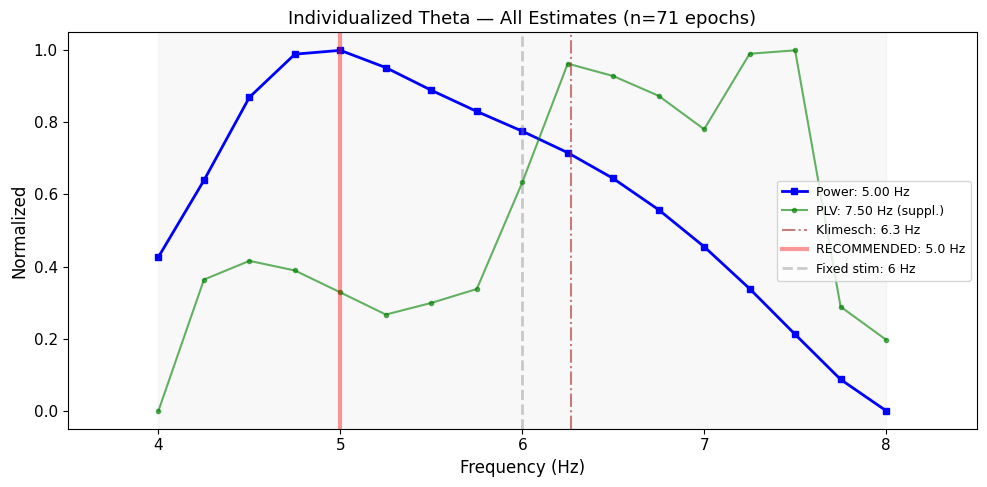

In [43]:
# Summary overlay: theta estimates
fig, ax = plt.subplots(figsize=(10, 5))

# Normalize spectra
theta_smooth = gaussian_filter1d(theta_spectrum, sigma=1.0)
pow_norm = (theta_smooth - theta_smooth.min()) / (theta_smooth.max() - theta_smooth.min() + 1e-12)
plv_norm = (plv_theta - plv_theta.min()) / (plv_theta.max() - plv_theta.min() + 1e-12)

ax.plot(theta_freqs_tfr, pow_norm, 'b-s', lw=2, ms=4, label=f'Power: {ITF_POWER:.2f} Hz')
ax.plot(theta_freqs_plv, plv_norm, 'g-o', lw=1.5, ms=3, alpha=0.6, label=f'PLV: {ITF_PLV:.2f} Hz (suppl.)')

if ITF_SPECPARAM:
    ax.axvline(ITF_SPECPARAM, color='purple', ls=':', lw=2, label=f'Specparam: {ITF_SPECPARAM:.2f} Hz')
ax.axvline(ITF_KLIMESCH, color='brown', ls='-.', lw=1.5, alpha=0.6, label=f'Klimesch: {ITF_KLIMESCH:.1f} Hz')
ax.axvline(theta_rec, color='red', ls='-', lw=3, alpha=0.4, label=f'RECOMMENDED: {theta_rec:.1f} Hz')
ax.axvline(STIM_FREQ_HZ, color='gray', ls='--', lw=2, alpha=0.4, label=f'Fixed stim: {STIM_FREQ_HZ:.0f} Hz')

ax.axvspan(*BANDS['theta'], alpha=0.05, color='gray')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Normalized')
ax.set_title(f'Individualized Theta — All Estimates (n={len(epochs_fb)} epochs)')
ax.legend(fontsize=9); ax.set_xlim(3.5, 8.5)
fig.tight_layout(); plt.show()


## Step 11: Export

In [46]:
import json
from datetime import datetime

export = {
    'subject_id': bdf['subject_id'].iloc[0],
    'session': int(bdf['session'].iloc[0]),
    'run': int(bdf['run'].iloc[0]),
    'created_at': datetime.now().isoformat(),
    'alignment_offset_sec': float(BEST_OFFSET),
    'n_epochs_feedback': len(epochs_fb),
    'n_epochs_decision': len(epochs_dec),
    'n_win': int(reward_flags.sum()),
    'n_loss': int((~reward_flags).sum()),
    'methods': {
        'primary': 'task-locked power peak (Bjekic et al., 2022)',
        'validation': 'specparam (Donoghue et al., 2020)',
        'supplementary': 'PLV (Reinhart & Nguyen, 2019)',
        'alpha_anchor': 'Klimesch (1999) IAF-5',
    },
    'theta': {
        'recommended_hz': theta_rec,
        'confidence': theta_conf,
        'power_based_hz': ITF_POWER,
        'specparam_hz': ITF_SPECPARAM,
        'plv_hz': float(ITF_PLV),
        'plv_peak_value': float(plv_theta.max()),
        'klimesch_hz': ITF_KLIMESCH,
        'band_hz': list(BANDS['theta']),
        'analysis_window_sec': list(FEEDBACK_WIN),
    },
    'beta': {
        'recommended_hz': beta_rec,
        'confidence': beta_conf,
        'feedback_power_hz': IBF_FB,
        'decision_erd_hz': IBF_DEC_ERD,
        'specparam_hz': IBF_SPECPARAM,
        'band_hz': list(BANDS['beta']),
    },
    'alpha': {
        'recommended_hz': alpha_rec,
        'confidence': alpha_conf,
        'posterior_psd_hz': IAF_POWER,
        'specparam_hz': IAF_SPECPARAM,
        'band_hz': list(BANDS['alpha']),
    },
    'theta_gamma_pac': {
        'modulation_index': float(pac_mi),
        'phase_band_hz': list(BANDS['theta']),
        'amp_band_hz': [25, 45],
        'note': 'Exploratory metric; not used for frequency selection',
    },
    'frequency_match': {
        'itf_hz': theta_rec,
        'stim_hz': STIM_FREQ_HZ,
        'distance_hz': freq_match,
        'note': 'Smaller distance may predict stronger tACS entrainment effect',
    },
    'frontal_roi': FRONTAL_ROI,
    'posterior_roi': POSTERIOR_ROI,
}

# Uncomment to save:
# out_path = BEHAV_CSV.parent / f"{bdf['subject_id'].iloc[0]}_freq_estimates.json"
# with open(out_path, 'w') as f:
#     json.dump(export, f, indent=2)
# print(f"Saved to: {out_path}")

print(json.dumps(export, indent=2, default=str))


{
  "subject_id": "rebecca-pilot-2",
  "session": 1,
  "run": 1,
  "created_at": "2026-06-05T11:24:28.506494",
  "alignment_offset_sec": -1.3999999999999995,
  "n_epochs_feedback": 71,
  "n_epochs_decision": 71,
  "n_win": 40,
  "n_loss": 31,
  "methods": {
    "primary": "task-locked power peak (Bjekic et al., 2022)",
    "validation": "specparam (Donoghue et al., 2020)",
    "supplementary": "PLV (Reinhart & Nguyen, 2019)",
    "alpha_anchor": "Klimesch (1999) IAF-5"
  },
  "theta": {
    "recommended_hz": 5.0,
    "confidence": "MODERATE",
    "power_based_hz": 5.0,
    "specparam_hz": null,
    "plv_hz": 7.5,
    "plv_peak_value": 0.2964650884557754,
    "klimesch_hz": 6.266448862127662,
    "band_hz": [
      4.0,
      8.0
    ],
    "analysis_window_sec": [
      0.1,
      1.5
    ]
  },
  "beta": {
    "recommended_hz": 13.0,
    "confidence": "LOW (single estimate)",
    "feedback_power_hz": 13.0,
    "decision_erd_hz": 22.5,
    "specparam_hz": null,
    "band_hz": [
      1

---

## Methodological Notes & References

### Frequency estimation approaches

**1. Task-locked power peak (PRIMARY)**
The frequency with peak event-related spectral perturbation (ERSP) at task-relevant electrodes during the task-relevant window. Bjekić et al. (2022, *J. Personalized Medicine*, doi:10.3390/jpm12091367) showed 93% success rate across 42 participants. Van Driel et al. (2015) used a similar approach with log-transformed, 1/f-detrended spectra during a cognitive inhibition task. This is the most appropriate method for single-site frontal stimulation targeting local oscillatory frequency.

**2. Spectral parameterization (VALIDATION)**
Donoghue et al. (2020, *Nature Neuroscience*, doi:10.1038/s41593-020-00744-x). Separates aperiodic (1/f) from periodic components, confirming whether a spectral peak reflects a genuine oscillation. Applied here to the feedback-window PSD. Addresses the concern (raised by our initial resting-state analysis) that apparent theta peaks can be artifacts of individual differences in aperiodic slope.

**3. PLV (SUPPLEMENTARY)**
Reinhart & Nguyen (2019, *Nature Neuroscience*, doi:10.1038/s41593-019-0371-x). Inter-regional phase synchronization to find the theta frequency with strongest frontotemporal coupling. Designed for two-site stimulation paradigms targeting inter-regional communication. Retained here for completeness and as a potential moderator variable, but not used for frequency selection because our single-site frontal stimulation targets local oscillatory entrainment rather than inter-regional coupling.

**4. IAF-anchored (Klimesch method)**
Klimesch (1999, *Brain Research Reviews*). Individual alpha frequency (IAF) serves as an anchor: ITF ≈ IAF − 5 Hz. Simple but makes assumptions about the relationship between alpha and theta peaks that don't hold universally. Used by Jaušovec & Jaušovec (2014) and Pahor & Jaušovec (2014) for theta-tACS in working memory. Reported here as a cross-reference.

### Band-specific task relevance

**Theta (4–8 Hz):** Feedback-locked frontal midline theta encodes reward prediction error (Cavanagh & Frank, 2014, *Trends in Cognitive Sciences*). The primary tACS target.

**Beta (13–30 Hz):** Pre-decision beta suppression (ERD) reflects decisional effort and distinguishes exploration from exploitation in probabilistic two-alternative tasks (Sporn et al., 2023, *Cerebral Cortex*). Post-feedback beta ERS reflects policy maintenance and information transfer to long-term memory (Holroyd et al., 2020, *Scientific Reports*, doi:10.1038/s41598-020-72128-x).

**Alpha (8–13 Hz):** Individual alpha frequency is the most reliable trait-like EEG measure and serves as an anchor. Alpha dynamics may index gating/inhibition during decision-making (Klimesch, 2012) but are not directly targeted by the stimulation.

### Theta-gamma PAC

Phase-amplitude coupling between theta phase and gamma amplitude is a candidate mechanism for memory encoding and RL value updating in hippocampo-cortical circuits (Tort et al., 2010; cross-frequency routing in probabilistic reversal learning). Measured here as an exploratory participant-level metric. The deficiency compensation hypothesis predicts that participants with weaker endogenous PAC may show larger tACS effects.

### Frequency match analysis

The distance between individualized theta frequency and the fixed stimulation frequency (|iTF − 6 Hz|) can be tested as a predictor of tACS behavioral effect size. Vosskuhl et al. (2015) found that closer proximity to the stimulation frequency predicted stronger behavioral effects after anti-phase theta-tACS.

### Limitations

- **7 electrodes:** Cannot do source localization, ICA, or high-density topographic mapping. Gamma estimates are noisy.
- **Single run:** 71 feedback epochs provide reasonable but not optimal power for PAC analysis. Pooling across multiple runs would improve reliability.
- **Alignment:** Empirical ERP-based alignment is robust but has ~100ms precision at best.
- **500 Hz sampling:** Adequate for theta through low-gamma but not for high-gamma analysis.
